In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_excel('../data/Suhu.xlsx')
df

,No,Suhu,Angin,Kelas
0,1,10,0,dingin
1,2,25,0,panas
2,3,15,5,dingin
3,4,20,3,panas
4,5,18,7,dingin
5,6,20,10,dingin
6,7,22,5,panas
7,8,24,6,panas


In [7]:
# Pisahkan Fitur (X) dan Label (y)
X_train = df[['Suhu', 'Angin']]
y_train = df['Kelas']

# Data Tes
X_test = np.array([[16, 3]]) # Suhu 16 , Angin 3 

In [8]:
# Membuat model k-NN dengan k=3
k_initial = 3
knn_model = KNeighborsClassifier(n_neighbors=k_initial)

# Melatih model
knn_model.fit(X_train, y_train)

# Memprediksi data tes
y_pred_test = knn_model.predict(X_test)

print(f"\nPrediksi Persepsi Marry untuk Suhu 16 dan Angin 3 (k={k_initial}):")
print(f"-> {y_pred_test[0]}")


Prediksi Persepsi Marry untuk Suhu 16 dan Angin 3 (k=3):
-> dingin


C:\Users\kenas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [9]:
# Membagi data (misal 6 data untuk latih, 2 data untuk uji internal)
X = df[['Suhu', 'Angin']].values
y = df['Kelas'].values

# Stratify=y memastikan proporsi kelas (Panas/Dingin) di set latih dan uji terjaga
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nSplit Data Internal (25% Test):")
print(f"Jumlah data latih internal: {len(X_train_int)}")
print(f"Jumlah data uji internal: {len(X_test_int)}")


Split Data Internal (25% Test):
Jumlah data latih internal: 6
Jumlah data uji internal: 2


In [10]:
# List untuk menyimpan akurasi
accuracies = []

# Mencoba nilai k dari 1 sampai 7 (N-1 data)
k_range = range(1, len(X_train_int))
max_accuracy = 0
best_k = 1

for k in k_range:
    # Inisialisasi model k-NN
    knn_model_k = KNeighborsClassifier(n_neighbors=k)
    
    # Latih model
    knn_model_k.fit(X_train_int, y_train_int)
    
    # Prediksi data uji internal
    y_pred_int = knn_model_k.predict(X_test_int)
    
    # Hitung akurasi
    accuracy = accuracy_score(y_test_int, y_pred_int)
    accuracies.append(accuracy)
    
    if accuracy > max_accuracy:
        max_accuracy = accuracy
        best_k = k

    print(f"k={k}: Akurasi = {accuracy:.2f}")

print(f"\nNilai k Terbaik (k-optimal) berdasarkan akurasi internal: **{best_k}** dengan Akurasi **{max_accuracy:.2f}**")

k=1: Akurasi = 1.00
k=2: Akurasi = 1.00
k=3: Akurasi = 1.00
k=4: Akurasi = 1.00
k=5: Akurasi = 0.50

Nilai k Terbaik (k-optimal) berdasarkan akurasi internal: **1** dengan Akurasi **1.00**


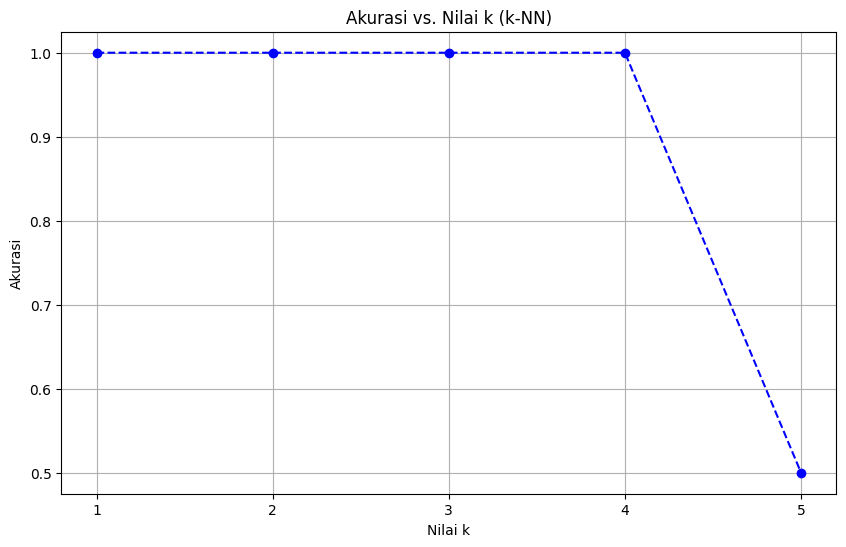

In [11]:
# Plot hasil
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='b')
plt.title('Akurasi vs. Nilai k (k-NN)')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## Persepsi Marry untuk Data Tes Suhu 16 dan angin 3 adalah: dingin
## Nilai k yang tepat berdasarkan akurasi terbaik: K=1, k=2, dan k=3